# Light Curve Contamination Analysis (GP Baseline Residuals)

**Target:** ASAS-SN ID 322336  
**Potential Contaminant:** ASASSN-V J051659.67-781752.9  
**Angular Separation:** ~15 arcsec

This notebook analyzes potential photometric contamination using GP baseline residuals.

## Methods
1. **GP Baseline Subtraction**: Remove long-term trends with per-camera GP baseline
2. **Temporal Overlap**: Match epochs where both sources have observations
3. **Correlation Analysis**: Check if target residuals correlate with contaminant
4. **Contamination Flux Estimation**: Estimate fractional flux contribution from PSF overlap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import sys

# Add repo root to path
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "malca").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.core.baseline import per_camera_gp_baseline

# Setup
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# File paths
TARGET_FILE = REPO_ROOT / "input/322336-light-curves.csv"
CONTAMINANT_FILE = REPO_ROOT / "input/ASASSN-V J051659.67-781752.9.csv"

# Separation in arcseconds
SEPARATION_ARCSEC = 15.0
ASASSN_FWHM_ARCSEC = 15.0

## 1. Load Light Curves

In [2]:
# Load target (has header comments)
df_target = pd.read_csv(TARGET_FILE, comment='#')
df_target.columns = df_target.columns.str.strip()

# Load contaminant
df_contam = pd.read_csv(CONTAMINANT_FILE)
df_contam.columns = df_contam.columns.str.strip()

# Standardize column names for target
df_target = df_target.rename(columns={
    'JD': 'JD', 'Mag': 'mag', 'Mag Error': 'error', 
    'Flux': 'flux', 'Flux Error': 'flux_err', 
    'Camera': 'camera#', 'Filter': 'filter'
})

# Standardize contaminant
df_contam = df_contam.rename(columns={
    'hjd': 'JD', 'mag': 'mag', 'mag_err': 'error',
    'camera': 'camera#'
})

print(f"Target: {len(df_target)} observations")
print(f"Contaminant: {len(df_contam)} observations")
print(f"\nTarget mag range: {df_target['mag'].min():.2f} - {df_target['mag'].max():.2f}")
print(f"Contaminant mag range: {df_contam['mag'].min():.2f} - {df_contam['mag'].max():.2f}")

Target: 1944 observations
Contaminant: 404 observations

Target mag range: 11.86 - 12.96
Contaminant mag range: 12.17 - 12.81


## 2. Apply GP Baseline to Target

In [3]:
# GP baseline parameters (long timescale)
gp_kwargs = {
    "sigma": 0.1,    # amplitude
    "rho": 200.0,    # characteristic timescale (days) - long baseline
    "q": 0.7,        # damping
    "jitter": 0.01,  # noise floor
}

# Apply GP baseline to target
print("Fitting GP baseline to target...")
df_target_gp = per_camera_gp_baseline(df_target, **gp_kwargs)

print(f"Baseline fit complete. Residual RMS: {df_target_gp['resid'].std():.4f} mag")

Fitting GP baseline to target...
Baseline fit complete. Residual RMS: 0.0143 mag


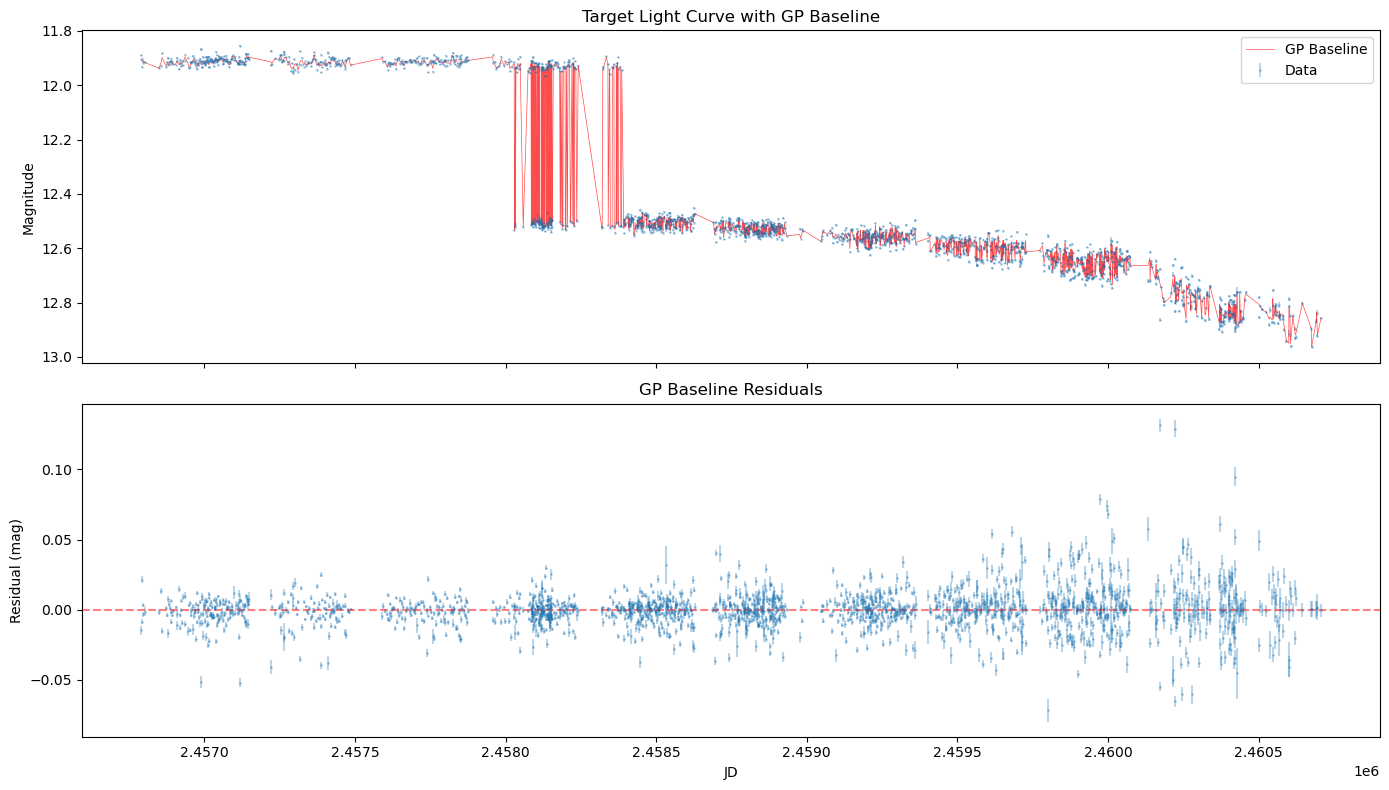

In [4]:
from malca.plotting.lightcurve_publication import plot_lightcurve_panel, plot_residual_panel, finalize_publication_figure

# Plot target with baseline
fig, axes = plt.subplots(2, 1, figsize=FIG_TWO_COL_STANDARD, sharex=True)

plot_lightcurve_panel(
    axes[0],
    df_target_gp,
    baseline=df_target_gp,
    baseline_col='baseline',
    baseline_time_col='JD',
    baseline_label='GP Baseline',
    baseline_style={'color': 'red', 'alpha': 0.7, 'linewidth': 0.5},
    group_by='none',
    show_errorbars=True,
    marker_size=2.0,
    time_offset='none',
    ylabel='Magnitude',
    title='Target Light Curve with GP Baseline',
)

plot_residual_panel(
    axes[1],
    df_target_gp,
    error_col='error',
    group_by='none',
    show_errorbars=True,
    marker_size=2.0,
    time_offset='none',
    xlabel='JD',
    ylabel='Residual (mag)',
    title='GP Baseline Residuals',
    invert_y=False,
)

finalize_publication_figure(plt.gcf())
plt.show()


## 3. Match Observations & Correlation Analysis

In [5]:
def match_observations(df1, df2, max_dt_days=0.5):
    """Match observations from two light curves taken within max_dt_days."""
    matches = []
    
    for _, row1 in df1.iterrows():
        jd1 = row1['JD']
        dt = np.abs(df2['JD'] - jd1)
        idx_closest = dt.idxmin()
        
        if dt[idx_closest] < max_dt_days:
            row2 = df2.loc[idx_closest]
            matches.append({
                'jd': jd1,
                'dt': dt[idx_closest],
                'target_resid': row1['resid'],
                'target_err': row1['error'],
                'contam_mag': row2['mag'],
                'contam_err': row2['error'],
            })
    
    return pd.DataFrame(matches)

# Match with 0.5 day tolerance
df_matched = match_observations(df_target_gp, df_contam, max_dt_days=0.5)
print(f"Found {len(df_matched)} matched observation pairs")

# Calculate contaminant residual from its median
contam_median = df_contam['mag'].median()
df_matched['contam_resid'] = df_matched['contam_mag'] - contam_median

Found 464 matched observation pairs


Pearson correlation: r = -0.081 (p = 8.27e-02)
Spearman correlation: ρ = -0.038 (p = 4.16e-01)


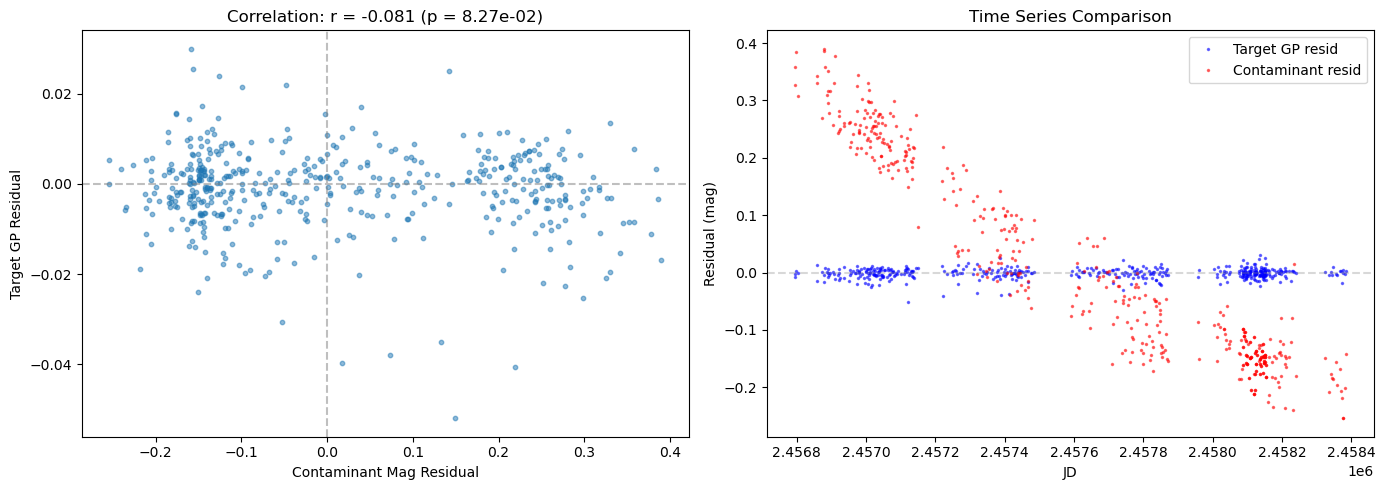

In [6]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
if len(df_matched) > 10:
    # Correlations
    r, p_value = stats.pearsonr(df_matched['target_resid'], df_matched['contam_resid'])
    rho, p_spearman = stats.spearmanr(df_matched['target_resid'], df_matched['contam_resid'])
    
    print(f"Pearson correlation: r = {r:.3f} (p = {p_value:.2e})")
    print(f"Spearman correlation: ρ = {rho:.3f} (p = {p_spearman:.2e})")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize_from_legacy(14, 5))
    
    # Scatter
    axes[0].scatter(df_matched['contam_resid'], df_matched['target_resid'], alpha=0.5, s=10)
    axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Contaminant Mag Residual')
    axes[0].set_ylabel('Target GP Residual')
    axes[0].set_title(f'Correlation: r = {r:.3f} (p = {p_value:.2e})')
    
    if p_value < 0.05:
        slope, intercept = np.polyfit(df_matched['contam_resid'], df_matched['target_resid'], 1)
        x_fit = np.linspace(df_matched['contam_resid'].min(), df_matched['contam_resid'].max(), 100)
        axes[0].plot(x_fit, slope * x_fit + intercept, 'r-', label=f'slope = {slope:.3f}')
        axes[0].legend()
    
    # Time series
    axes[1].plot(df_matched['jd'], df_matched['target_resid'], 'b.', 
                 label='Target GP resid', alpha=0.5, markersize=3)
    axes[1].plot(df_matched['jd'], df_matched['contam_resid'], 'r.', 
                 label='Contaminant resid', alpha=0.5, markersize=3)
    axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[1].set_xlabel('JD')
    axes[1].set_ylabel('Residual (mag)')
    axes[1].legend()
    axes[1].set_title('Time Series Comparison')
    
    finalize_publication_figure(plt.gcf())
    plt.show()


## 4. PSF Contamination Estimate

In [7]:
def gaussian_psf_overlap(separation_arcsec, fwhm_arcsec):
    """Calculate fractional flux at separation for Gaussian PSF."""
    sigma = fwhm_arcsec / (2 * np.sqrt(2 * np.log(2)))
    return np.exp(-(separation_arcsec**2) / (2 * sigma**2))

mean_target_mag = df_target['mag'].median()
mean_contam_mag = df_contam['mag'].median()
contam_amp = (df_contam['mag'].max() - df_contam['mag'].min()) / 2
flux_ratio = 10**((mean_target_mag - mean_contam_mag) / 2.5)

print(f"Target median mag: {mean_target_mag:.2f}")
print(f"Contaminant median mag: {mean_contam_mag:.2f}")
print(f"Contaminant amplitude: ±{contam_amp:.3f} mag")
print(f"Flux ratio (contam/target): {1/flux_ratio:.4f}")

print("\n" + "="*60)
for fwhm in [12, 15, 18, 20]:
    overlap = gaussian_psf_overlap(SEPARATION_ARCSEC, fwhm)
    contam_flux_frac = overlap / flux_ratio
    contam_flux_var = 10**(contam_amp / 2.5) - 1
    effect_mag = 2.5 * np.log10(1 + overlap * contam_flux_var / flux_ratio)
    
    print(f"FWHM={fwhm}\": overlap={overlap*100:.1f}%, "
          f"contam flux={contam_flux_frac*100:.2f}%, effect=±{effect_mag*1000:.1f} mmag")

Target median mag: 12.53
Contaminant median mag: 12.42
Contaminant amplitude: ±0.322 mag
Flux ratio (contam/target): 0.9032

FWHM=12": overlap=1.3%, contam flux=1.19%, effect=±4.4 mmag
FWHM=15": overlap=6.3%, contam flux=5.65%, effect=±21.0 mmag
FWHM=18": overlap=14.6%, contam flux=13.17%, effect=±48.3 mmag
FWHM=20": overlap=21.0%, contam flux=18.99%, effect=±68.9 mmag


## 5. Summary

In [8]:
print("="*60)
print("CONTAMINATION ANALYSIS SUMMARY (GP RESIDUALS)")
print("="*60)

print(f"\n1. SOURCE PROPERTIES")
print(f"   Target median mag: {mean_target_mag:.2f}")
print(f"   Contaminant median mag: {mean_contam_mag:.2f}")
print(f"   Angular separation: {SEPARATION_ARCSEC} arcsec")
print(f"   Contaminant amplitude: ±{contam_amp:.3f} mag")

print(f"\n2. GP BASELINE FIT")
print(f"   GP params: sigma={gp_kwargs['sigma']}, rho={gp_kwargs['rho']} days")
print(f"   Target residual RMS: {df_target_gp['resid'].std():.4f} mag")

print(f"\n3. MATCHED OBSERVATIONS")
print(f"   Matched pairs: {len(df_matched)}")

if len(df_matched) > 10:
    print(f"\n4. CORRELATION (GP RESIDUALS vs CONTAMINANT)")
    print(f"   Pearson r: {r:.3f} (p = {p_value:.2e})")
    print(f"   Spearman ρ: {rho:.3f} (p = {p_spearman:.2e})")
    if p_value < 0.05:
        print(f"   → SIGNIFICANT correlation detected!")
        print(f"   → Slope: {slope:.4f} (target mag change per contam mag change)")
    else:
        print(f"   → No significant correlation")

print(f"\n5. PSF CONTAMINATION ESTIMATE (FWHM=15\")")
overlap_15 = gaussian_psf_overlap(SEPARATION_ARCSEC, 15)
print(f"   PSF overlap fraction: {overlap_15*100:.2f}%")
print(f"   Contaminant flux in aperture: {overlap_15/flux_ratio*100:.2f}% of target")

print("\n" + "="*60)

CONTAMINATION ANALYSIS SUMMARY (GP RESIDUALS)

1. SOURCE PROPERTIES
   Target median mag: 12.53
   Contaminant median mag: 12.42
   Angular separation: 15.0 arcsec
   Contaminant amplitude: ±0.322 mag

2. GP BASELINE FIT
   GP params: sigma=0.1, rho=200.0 days
   Target residual RMS: 0.0143 mag

3. MATCHED OBSERVATIONS
   Matched pairs: 464

4. CORRELATION (GP RESIDUALS vs CONTAMINANT)
   Pearson r: -0.081 (p = 8.27e-02)
   Spearman ρ: -0.038 (p = 4.16e-01)
   → No significant correlation

5. PSF CONTAMINATION ESTIMATE (FWHM=15")
   PSF overlap fraction: 6.25%
   Contaminant flux in aperture: 5.65% of target

